# CT Scan Colorization with U-Net

This self-learning tutorial walks through building an image-to-image model (U-Net) to colorize grayscale brain CT images using a public Kaggle dataset. It covers: environment setup, dataset download, PyTorch Dataset/DataLoader, model, training loop with evaluation (PSNR/SSIM), and inference/visualization.

What you’ll learn
- Data handling: robustly locating the dataset and building a labeled DataFrame
- Writing a custom PyTorch Dataset and DataLoaders
- Implementing a U-Net for image-to-image translation
- Training with a clean loop, metrics (PSNR/SSIM), and checkpointing
- Running inference and visualizing results

Replicability tips
- Run cells top-to-bottom. The setup cell installs required packages.
- This notebook detects Colab and optionally mounts Drive. Locally, it skips those steps.
- Random seeds are fixed for reproducibility, but GPU/CPU differences can still cause tiny variations.
- If KaggleHub download fails, manually download the dataset and set dataset_path accordingly in the data cell.

Ethical note
Colorizing CT scans is for demonstration only and isn’t intended for clinical decision-making. Be careful not to imply diagnostic value without validation.


Dataset – “Brain CT Medical Imaging Colorized Dataset”

Shuvo Kumar Basak. (2025). Brain CT Medical Imaging Colorized Dataset [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/11886200



In [20]:
"""
@misc{shuvo_kumar_basak_2025,
	title={Brain CT Medical Imaging Colorized Dataset},
	url={https://www.kaggle.com/dsv/11886200},
	DOI={10.34740/KAGGLE/DSV/11886200},
	publisher={Kaggle},
	author={Shuvo Kumar Basak},
	year={2025}
}
"""

'\n@misc{shuvo_kumar_basak_2025,\n\ttitle={Brain CT Medical Imaging Colorized Dataset},\n\turl={https://www.kaggle.com/dsv/11886200},\n\tDOI={10.34740/KAGGLE/DSV/11886200},\n\tpublisher={Kaggle},\n\tauthor={Shuvo Kumar Basak},\n\tyear={2025}\n}\n'

In [21]:
# Installing/Ensuring Torch, Scikit-Image, OpenCV are installed
import sys, subprocess, importlib

def pip_install(pkgs):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pkgs])
    except Exception as e:
        print("Install warning:", e)

# Minimal set; torchvision pulls pillow; add kagglehub if used
pip_install(["torch", "torchvision", "torchaudio", "tqdm", "opencv-python", "scikit-image", "pandas", "kagglehub"])

In [22]:
# Importing libraries
import os, glob, shutil, random
from pathlib import Path

import numpy as np
from math import log10
import cv2

import pandas as pd
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import torch
from torchvision import transforms
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm import trange, tqdm

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [23]:
# Download latest version of dataset via kagglehub
import kagglehub

try:
    path = kagglehub.dataset_download("shuvokumarbasakbd/brain-ct-medical-imaging-colorized-dataset")
    print("Downloaded to:", path)
except Exception as e:
    print("KaggleHub download failed:", e)
    path = None

Using Colab cache for faster access to the 'brain-ct-medical-imaging-colorized-dataset' dataset.
Downloaded to: /kaggle/input/brain-ct-medical-imaging-colorized-dataset


In [24]:
# Optional: Mount Google Drive in Colab and copy dataset (skipped locally)
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    if path is not None:
        print("Path to dataset files:", path)
        destination_path = '/content/drive/MyDrive/brain-ct-medical-imaging-colorized-dataset'
        try:
            shutil.copytree(path, destination_path)
            print(f"Dataset successfully copied to Google Drive: {destination_path}")
        except FileExistsError:
            print(f"Dataset already exists in Google Drive: {destination_path}")
        except Exception as e:
            print(f"Error copying dataset to Google Drive: {e}")
else:
    print("Not running in Colab; skipping Drive mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Path to dataset files: /kaggle/input/brain-ct-medical-imaging-colorized-dataset
Dataset already exists in Google Drive: /content/drive/MyDrive/brain-ct-medical-imaging-colorized-dataset


In [25]:
# Build a DataFrame of image paths and labels with robust base path detection

# Try common KaggleHub cache roots
def guess_base_path(download_path):
    candidates = []
    if download_path:
        candidates.append(download_path)
    candidates += [
        # kagglehub default cache
        os.path.expanduser("~/.cache/kagglehub/datasets/shuvokumarbasakbd/brain-ct-medical-imaging-colorized-dataset/versions/1"),

        # Known Colab path
        "/root/.cache/kagglehub/datasets/shuvokumarbasakbd/brain-ct-medical-imaging-colorized-dataset/versions/1",
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None

base_dataset_path = guess_base_path(path)
if base_dataset_path is None:
    raise FileNotFoundError("Dataset base path not found. If you downloaded manually, set base_dataset_path to your root folder.")

# Dataset’s internal structure
root_rel = os.path.join("Computed Tomography (CT) of the Brain", "dataset")
dataset_path = os.path.join(base_dataset_path, root_rel)

splits = ["train", "test"]
classes = ["aneurysm", "cancer", "tumor"]

records = []
for split in splits:
    for label, cls in enumerate(classes):
        img_dir = os.path.join(dataset_path, split, cls)
        if not os.path.isdir(img_dir):
            print("Skipping missing dir:", img_dir)
            continue
        for img_name in os.listdir(img_dir):
            if not img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            records.append({
                "img_path": os.path.join(img_dir, img_name),
                "label": label,
                "split": split,
                "class": cls,
                "img_name": img_name
            })

df = pd.DataFrame(records)
print("Samples per split:\n", df.groupby(["split", "class"]).size())
df.head()

Samples per split:
 split  class   
test   aneurysm     48
       cancer       48
       tumor        48
train  aneurysm    840
       cancer      910
       tumor       840
dtype: int64


,img_path,label,split,class,img_name
0,/kaggle/input/brain-ct-medical-imaging-coloriz...,0,train,aneurysm,43_11.jpg
1,/kaggle/input/brain-ct-medical-imaging-coloriz...,0,train,aneurysm,56_4.jpg
2,/kaggle/input/brain-ct-medical-imaging-coloriz...,0,train,aneurysm,3_7.jpg
3,/kaggle/input/brain-ct-medical-imaging-coloriz...,0,train,aneurysm,12_12.jpg
4,/kaggle/input/brain-ct-medical-imaging-coloriz...,0,train,aneurysm,19_3.jpg


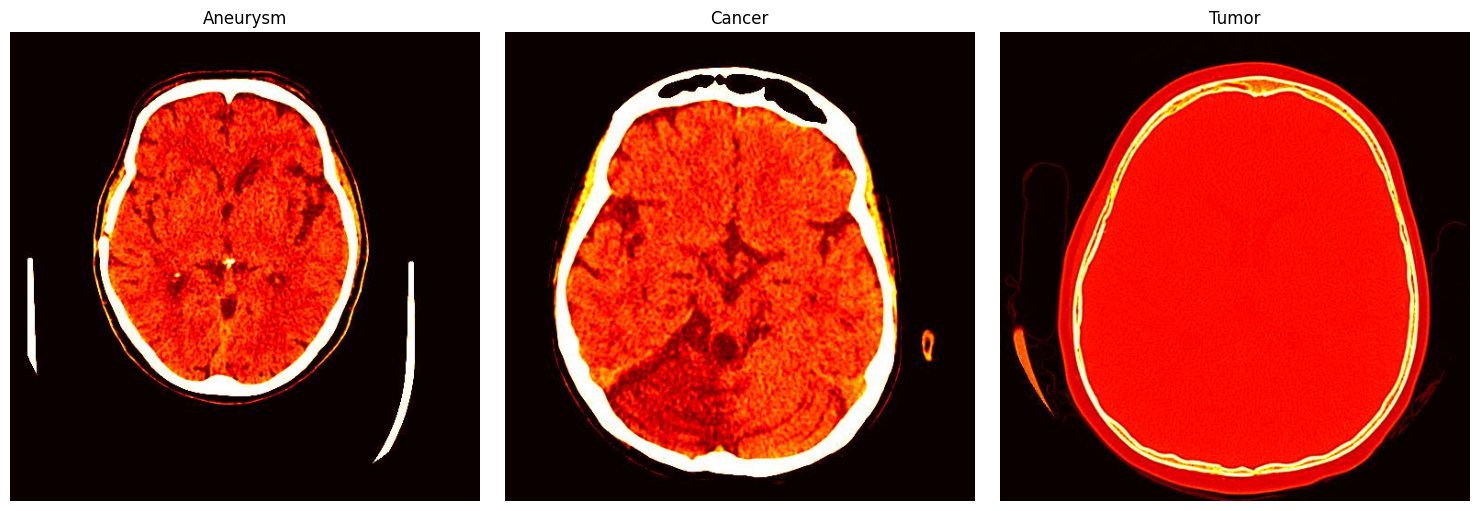

In [26]:
# Visual sanity check: one image per class from the train split
base_path = os.path.join(base_dataset_path, "Computed Tomography (CT) of the Brain", "dataset")
categories = ["aneurysm", "cancer", "tumor"]

plt.figure(figsize=(15, 5))
for i, category in enumerate(categories):
    category_path = os.path.join(base_path, 'train', category)
    if not os.path.isdir(category_path):
        print(f"Missing: {category_path}")
        continue
    image_files = [f for f in os.listdir(category_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    if image_files:
        img_name = image_files[0]
        img_path = os.path.join(category_path, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.title(category.capitalize())
        plt.axis('off')
    else:
        print(f"No images found for category: {category}")
plt.tight_layout()
plt.show()

## Define a custom dataset class

### Subtask:
Create a new PyTorch `Dataset` class that takes the `df` DataFrame as input.


**Reasoning**:
Define a new PyTorch Dataset class `CTScanDataset` that takes the DataFrame `df` as input and initializes necessary variables.



In [27]:
class CTScanDataset(Dataset):
    def __init__(self, df, img_size=256, augment=False):
        self.df = df
        self.img_size = img_size
        self.augment = augment

        self.transform_input = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)) # Normalize grayscale input
        ])

        self.transform_target = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize color target
        ])


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['img_path']

        # Load the original color image as the target
        target_image = Image.open(img_path).convert("RGB")

        # Convert the color image to grayscale for the input
        input_image = target_image.convert("L")

        if self.augment:
            # Apply augmentations if needed (e.g., random horizontal/vertical flip, rotation)
            # Augmentations should be applied consistently to both input and target images if they affect spatial position
            if np.random.rand() > 0.5:
                input_image = transforms.functional.hflip(input_image)
                target_image = transforms.functional.hflip(target_image)
            if np.random.rand() > 0.5:
                input_image = transforms.functional.vflip(input_image)
                target_image = transforms.functional.vflip(target_image)
            # Add more augmentations as needed, applying to both input and target

        input_image = self.transform_input(input_image)
        target_image = self.transform_target(target_image)


        # For single-channel input, replicate the channel 3 times for some models
        input_img_replicated = torch.cat([input_image]*3, dim=0)


        return input_img_replicated, target_image

## Create dataloaders

### Subtask:
Use the custom dataset class to create PyTorch `DataLoader` instances for training and validation/testing.


**Reasoning**:
Define the train and validation splits from the `df` DataFrame and instantiate the custom dataset classes for training and validation.



In [28]:
# Train/Val split DataFrames
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'test'].reset_index(drop=True)

train_dataset = CTScanDataset(train_df, augment=True)
val_dataset = CTScanDataset(val_df, augment=False)

**Reasoning**:
Create PyTorch DataLoaders for the training and validation datasets using the instantiated dataset classes.



In [29]:
batch_size = 32
num_workers = 2

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 81
Number of validation batches: 5


In [30]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pad=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel, padding=pad)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel, padding=pad)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        return x

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        c = self.conv(x)
        p = self.pool(c)
        return c, p

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

class UNetColoriser(nn.Module):
    def __init__(self, in_ch=3, out_ch=3):
        super().__init__()
        self.enc1 = EncoderBlock(in_ch, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        self.bottleneck = ConvBlock(512, 1024)

        self.dec4 = DecoderBlock(1024, 512, 512)
        self.dec3 = DecoderBlock(512, 256, 256)
        self.dec2 = DecoderBlock(256, 128, 128)
        self.dec1 = DecoderBlock(128, 64, 64)

        self.out = nn.Conv2d(64, out_ch, kernel_size=1)   # 3‑channel output

    def forward(self, x):
        c1, p1 = self.enc1(x)
        c2, p2 = self.enc2(p1)
        c3, p3 = self.enc3(p2)
        c4, p4 = self.enc4(p3)

        bott = self.bottleneck(p4)

        d4 = self.dec4(bott, c4)
        d3 = self.dec3(d4, c3)
        d2 = self.dec2(d3, c2)
        d1 = self.dec1(d2, c1)

        return torch.tanh(self.out(d1))   # keep output in [-1,1]


In [31]:
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.l2 = nn.MSELoss()
        self.alpha = alpha

    def forward(self, pred, target):
        return self.alpha * self.l1(pred, target) + (1-self.alpha) * self.l2(pred, target)


In [32]:
# Image quality metrics wrappers expecting tensors in [-1,1]

def tensor_to_img01(x):
    # x: tensor [B,C,H,W] or [C,H,W] in [-1,1] -> numpy [H,W,C] in [0,1]
    if x.dim() == 4:
        x = x[0]
    x = (x.clamp(-1,1) + 1) / 2
    x = x.permute(1,2,0).cpu().numpy()
    return x

def psnr_metric(pred, target):
    p = tensor_to_img01(pred)
    t = tensor_to_img01(target)
    return sk_psnr(t, p, data_range=1.0)

def ssim_metric(pred, target):
    p = tensor_to_img01(pred)
    t = tensor_to_img01(target)
    return sk_ssim(t, p, data_range=1.0, channel_axis=2)

In [16]:
# Training loop with validation and checkpointing

DEVICE = device
NUM_EPOCHS = 5  # reduce for demo; increase to 30+ for better results
BATCH_SIZE = 16
IMG_SIZE = 256

model = UNetColoriser().to(DEVICE)
criterion = CombinedLoss(alpha=0.4)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for inp, tgt in tqdm(train_loader, leave=False):
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tgt)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inp.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    val_psnr = 0.0
    val_ssim = 0.0
    with torch.no_grad():
        for inp, tgt in val_loader:
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            out = model(inp)
            loss = criterion(out, tgt)
            val_loss += loss.item() * inp.size(0)

            # Metrics (accumulate per image)
            for b in range(out.size(0)):
                val_psnr += psnr_metric(out[b], tgt[b])
                val_ssim += ssim_metric(out[b], tgt[b])

    val_loss /= len(val_loader.dataset)
    val_psnr /= len(val_loader.dataset)
    val_ssim /= len(val_loader.dataset)

    scheduler.step()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | PSNR: {val_psnr:.2f} | SSIM: {val_ssim:.4f}")

    # Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_ct_coloriser.pth")
        print("Saved checkpoint: best_ct_coloriser.pth")

Epoch 1/5 | Train Loss: 0.3151 | Val Loss: 0.1979 | PSNR: 14.44 | SSIM: 0.5311
Saved checkpoint: best_ct_coloriser.pth


Epoch 2/5 | Train Loss: 0.1762 | Val Loss: 0.1527 | PSNR: 15.98 | SSIM: 0.5923
Saved checkpoint: best_ct_coloriser.pth


Epoch 3/5 | Train Loss: 0.1394 | Val Loss: 0.1235 | PSNR: 16.89 | SSIM: 0.6718
Saved checkpoint: best_ct_coloriser.pth


Epoch 4/5 | Train Loss: 0.1180 | Val Loss: 0.1109 | PSNR: 17.51 | SSIM: 0.6954
Saved checkpoint: best_ct_coloriser.pth


Epoch 5/5 | Train Loss: 0.1036 | Val Loss: 0.1009 | PSNR: 17.78 | SSIM: 0.6979
Saved checkpoint: best_ct_coloriser.pth


In [17]:
# Inference utility

def inference(model_path, input_path, output_path, img_size=256, device=device):
    model = UNetColoriser().to(device)
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.eval()

    inp_img = Image.open(input_path).convert("L")
    inp_img = transforms.Resize((img_size,img_size))(inp_img)
    inp_img = transforms.ToTensor()(inp_img)
    inp_img = transforms.Normalize((0.5,), (0.5,))(inp_img)
    inp_img = torch.cat([inp_img]*3, dim=0).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(inp_img)
    out_img = out.squeeze(0)   # 3×H×W
    out_np  = (out_img.clamp(-1,1).permute(1,2,0).cpu().numpy() + 1)/2   # back to [0,1]
    cv2.imwrite(output_path, (out_np*255).astype(np.uint8)[:,:,::-1])  # BGR order for OpenCV

In [18]:
# Mixed precision training example (requires CUDA)
if torch.cuda.is_available():
    scaler = torch.cuda.amp.GradScaler()
    model.train()
    for inp, tgt in train_loader:
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            out  = model(inp)
            loss = criterion(out, tgt)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
else:
    print("CUDA not available; skipping AMP example.")

/tmp/ipython-input-2501375829.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-2501375829.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


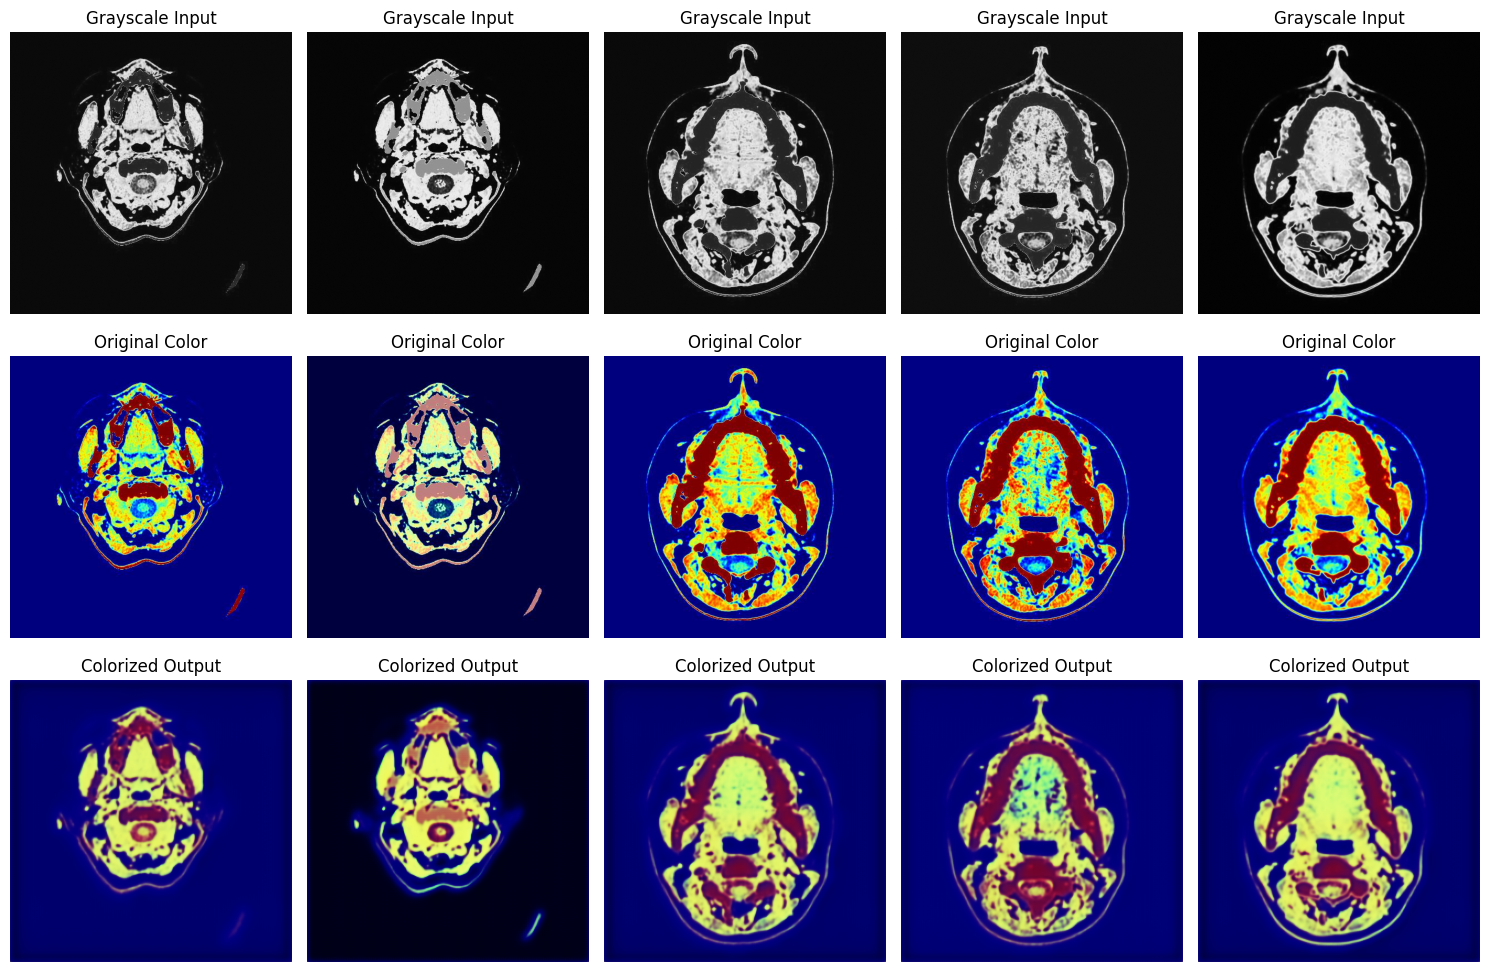

In [19]:
# Visualize a few predictions vs targets

# Prepare a few samples from validation dataset
n_samples = min(5, len([i for i in range(len(df)) if df.iloc[i]['split']=='test']))
sample_indices = random.sample(list(df.index[df['split']=='test']), n_samples)

# Make sure checkpoint exists (else fall back to current model weights)
model_path = "best_ct_coloriser.pth"
if not os.path.exists(model_path):
    torch.save(model.state_dict(), model_path)

output_dir = "colorized_outputs"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(sample_indices):
    img_path = df.loc[idx, 'img_path']

    # Build input grayscale from original image
    target_pil = Image.open(img_path).convert("RGB")
    input_pil = target_pil.convert("L")

    temp_input_path = os.path.join(output_dir, f"input_{i}.png")
    temp_target_path = os.path.join(output_dir, f"target_{i}.png")
    temp_output_path = os.path.join(output_dir, f"output_{i}.png")

    input_pil.save(temp_input_path)
    target_pil.save(temp_target_path)

    inference(model_path, temp_input_path, temp_output_path, img_size=IMG_SIZE, device=DEVICE)

    original_img = mpimg.imread(temp_target_path)
    input_img_display = mpimg.imread(temp_input_path)
    colorized_img = mpimg.imread(temp_output_path)

    plt.subplot(3, n_samples, i + 1)
    plt.imshow(input_img_display, cmap='gray')
    plt.title("Grayscale Input")
    plt.axis('off')

    plt.subplot(3, n_samples, i + 1 + n_samples)
    plt.imshow(original_img)
    plt.title("Original Color")
    plt.axis('off')

    plt.subplot(3, n_samples, i + 1 + 2*n_samples)
    plt.imshow(colorized_img)
    plt.title("Colorized Output")
    plt.axis('off')

plt.tight_layout()
plt.show()